In [ ]:
from google.colab import files
upload = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


In [ ]:
import pandas as pd
df = pd.read_csv("SMSSpamCollection",sep="\t",
    header=None,
    names=["label", "message"]
)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.isnull().sum()

,0
label,0
message,0


In [ ]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df = df.drop_duplicates().copy()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["char_count"] = df["message"].str.len()

df["word_count"] = df["message"].str.split().str.len()

In [ ]:
df.head()

,label,message,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [ ]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,5169.000000,5169.000000
mean,79.344554,15.439930
std,58.437457,11.117073
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,119.000000,22.000000
max,910.000000,171.000000


In [ ]:
df.groupby("label")[["char_count", "word_count"]].mean()

,char_count,word_count
label,,
ham,70.905890,14.239814
spam,137.704441,23.739663


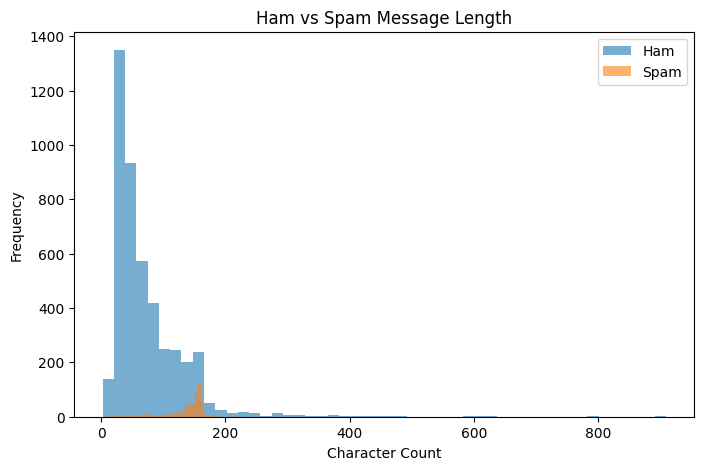

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df[df["label"]=="ham"]["char_count"],
         bins=50,
         alpha=0.6,
         label="Ham")

plt.hist(df[df["label"]=="spam"]["char_count"],
         bins=50,
         alpha=0.6,
         label="Spam")

plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.title("Ham vs Spam Message Length")
plt.legend()

plt.show()

<Figure size 600x500 with 0 Axes>

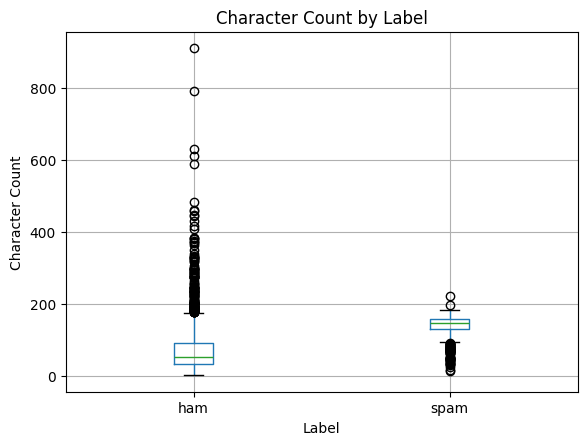

In [ ]:
plt.figure(figsize=(6,5))

df.boxplot(column="char_count", by="label")

plt.title("Character Count by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Character Count")

plt.show()

In [ ]:
from collections import Counter

def get_top_words(messages, n=20):
    words = []

    for msg in messages:
        words.extend(msg.lower().split())

    return Counter(words).most_common(n)

In [ ]:
ham_words = get_top_words(df[df["label"]=="ham"]["message"])

ham_words

[('i', 2070),
 ('you', 1610),
 ('to', 1471),
 ('the', 1054),
 ('a', 965),
 ('and', 816),
 ('u', 801),
 ('in', 730),
 ('my', 670),
 ('is', 635),
 ('me', 565),
 ('for', 476),
 ('of', 472),
 ('that', 432),
 ('have', 420),
 ('it', 419),
 ('but', 397),
 ('are', 390),
 ('so', 387),
 ('your', 378)]

In [ ]:
spam_words = get_top_words(df[df["label"]=="spam"]["message"])

spam_words

[('to', 594),
 ('a', 330),
 ('call', 298),
 ('your', 241),
 ('you', 226),
 ('for', 183),
 ('the', 181),
 ('free', 157),
 ('or', 157),
 ('2', 151),
 ('is', 138),
 ('on', 119),
 ('ur', 119),
 ('from', 118),
 ('have', 115),
 ('txt', 114),
 ('and', 104),
 ('text', 96),
 ('u', 96),
 ('mobile', 95)]

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

In [ ]:
stop_words = set(stopwords.words("english"))

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess(text):

    # lowercase
    text = text.lower()

    # punctuation remove
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    cleaned = []

    for word in words:

        if word not in stop_words:
            cleaned.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned)

In [ ]:
df["clean_message"] = df["message"].apply(preprocess)

In [ ]:
df[["message","clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [ ]:
ham_words = get_top_words(df[df["label"]=="ham"]["clean_message"])
spam_words = get_top_words(df[df["label"]=="spam"]["clean_message"])

print(ham_words)
print()
print(spam_words)

[('u', 942), ('im', 436), ('get', 306), ('2', 292), ('go', 268), ('ltgt', 254), ('dont', 248), ('ok', 247), ('know', 229), ('got', 226), ('come', 226), ('like', 224), ('good', 208), ('ill', 207), ('time', 205), ('ur', 202), ('call', 195), ('day', 193), ('want', 180), ('love', 179)]

[('call', 314), ('free', 188), ('2', 155), ('u', 130), ('txt', 126), ('text', 120), ('ur', 119), ('mobile', 114), ('stop', 105), ('claim', 98), ('4', 97), ('reply', 94), ('prize', 82), ('get', 69), ('new', 64), ('service', 64), ('tone', 62), ('send', 58), ('urgent', 58), ('nokia', 54)]


In [ ]:
def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    # Add this line
    text = text.replace("ltgt", " ")

    words = text.split()

    cleaned = []

    for word in words:
        if word not in stop_words:
            cleaned.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned)

In [ ]:
df["clean_message"] = df["message"].apply(preprocess)

In [ ]:
spam_words = get_top_words(df[df["label"]=="spam"]["clean_message"])

spam_words

[('call', 314),
 ('free', 188),
 ('2', 155),
 ('u', 130),
 ('txt', 126),
 ('text', 120),
 ('ur', 119),
 ('mobile', 114),
 ('stop', 105),
 ('claim', 98),
 ('4', 97),
 ('reply', 94),
 ('prize', 82),
 ('get', 69),
 ('new', 64),
 ('service', 64),
 ('tone', 62),
 ('send', 58),
 ('urgent', 58),
 ('nokia', 54)]

In [ ]:
ham_words = get_top_words(df[df["label"]=="ham"]["clean_message"])

ham_words

[('u', 942),
 ('im', 436),
 ('get', 306),
 ('2', 292),
 ('go', 268),
 ('dont', 248),
 ('ok', 247),
 ('know', 229),
 ('got', 226),
 ('come', 226),
 ('like', 224),
 ('good', 208),
 ('ill', 207),
 ('time', 205),
 ('ur', 202),
 ('call', 195),
 ('day', 193),
 ('want', 180),
 ('love', 179),
 ('ü', 169)]

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 7792)
(1034, 7792)


In [ ]:
print(len(tfidf.vocabulary_))

7792


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = nb.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.965183752417795

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.97      0.68      0.80       131

    accuracy                           0.96      1034
   macro avg       0.96      0.84      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
msg = "dilsahd claim ur 2lakh prize urgent."

clean = preprocess(msg)

vector = tfidf.transform([clean])

prediction = svm.predict(vector)

print(prediction)

['spam']


In [ ]:
%who

Counter	 LinearSVC	 LogisticRegression	 MultinomialNB	 TfidfVectorizer	 WordNetLemmatizer	 X	 X_test	 X_test_tfidf	 
X_train	 X_train_tfidf	 accuracy_score	 classification_report	 clean	 df	 files	 get_top_words	 ham_words	 
lemmatizer	 lr	 msg	 nb	 nltk	 pd	 plt	 prediction	 preprocess	 
spam_words	 stop_words	 stopwords	 string	 svm	 tfidf	 train_test_split	 upload	 vector	 
y	 y_pred	 y_pred_lr	 y_pred_svm	 y_test	 y_train	 
